**we need to subsample the cells from this space - now the distribution is non uniform so the result would be biased**  

created 04/21/2025


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import matplotlib.pyplot as plt 

In [2]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [3]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [4]:
adata_mer.X.max()

0.24816138

In [5]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [25]:
from collections import defaultdict

n_bins = (3,5)  # number of bins along the X and Y spatial axes
random_seed = 0
np.random.seed(random_seed)

# Extract your data
S = adata_mer.obsm['spatial']       # shape (N, 3)
S = get_hemi(S, mesh_LC) 
X = adata_mer.X                     # shape (N, G)

# Compute bin edges along the first two dimensions
x_edges = np.linspace(S[:,0].min(), S[:,0].max(), n_bins[0] + 1)
y_edges = np.linspace(S[:,1].min(), S[:,1].max(), n_bins[1] + 1)

# Assign each cell to a bin
bin_to_idx = defaultdict(list)
for i, (x, y) in enumerate(S[:, :2]):
    xi = np.searchsorted(x_edges, x, side='right') - 1
    yi = np.searchsorted(y_edges, y, side='right') - 1
    if 0 <= xi < n_bins[0] and 0 <= yi < n_bins[1]:
        bin_to_idx[(xi, yi)].append(i)

# Determine how many cells to take per bin (e.g. minimum bin size)
bin_counts = [len(idxs) for idxs in bin_to_idx.values() if idxs]
target_per_bin = min(bin_counts)

# Subsample indices
selected_idx = []
for idxs in bin_to_idx.values():
    if len(idxs) >= target_per_bin:
        chosen = np.random.choice(idxs, target_per_bin, replace=False)
    else:
        chosen = idxs  # keep all if fewer than the target
    selected_idx.extend(chosen)

# Create a subsampled AnnData for downstream CCA
adata_sub = adata_mer[selected_idx].copy()

print(adata_sub.shape)

(165, 315)


# solution1 is to run PCA on the sample space 

In [59]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

# 1. Subsample as before → adata_sub
X_sub = adata_sub.X
S_sub = adata_sub.obsm['spatial']  # first two dims

# 2. Standardize
scalerX = StandardScaler().fit(X_sub)
scalerS = StandardScaler().fit(S_sub)
Xs = scalerX.transform(X_sub)
Ss = scalerS.transform(S_sub)

# 3. PCA on X to, say, 30 components (30 < n_samples)
pca = PCA(n_components=20)
X_pca = pca.fit_transform(Xs)

# 5. Run CCA on the reduced data
cca = CCA(n_components=3)
X_c, S_c = cca.fit_transform(X_pca, Ss)

# 6. Check correlations
import numpy as np
canonical_correlations = [np.corrcoef(X_c[:,i], S_c[:,i])[0,1] for i in range(3)]
print("canonical correlations:", canonical_correlations)


canonical correlations: [0.9125600629481553, 0.6652298200090633, 0.3412353022373969]


In [60]:
Xs.shape

(165, 315)

In [61]:
X_pca.shape

(165, 20)

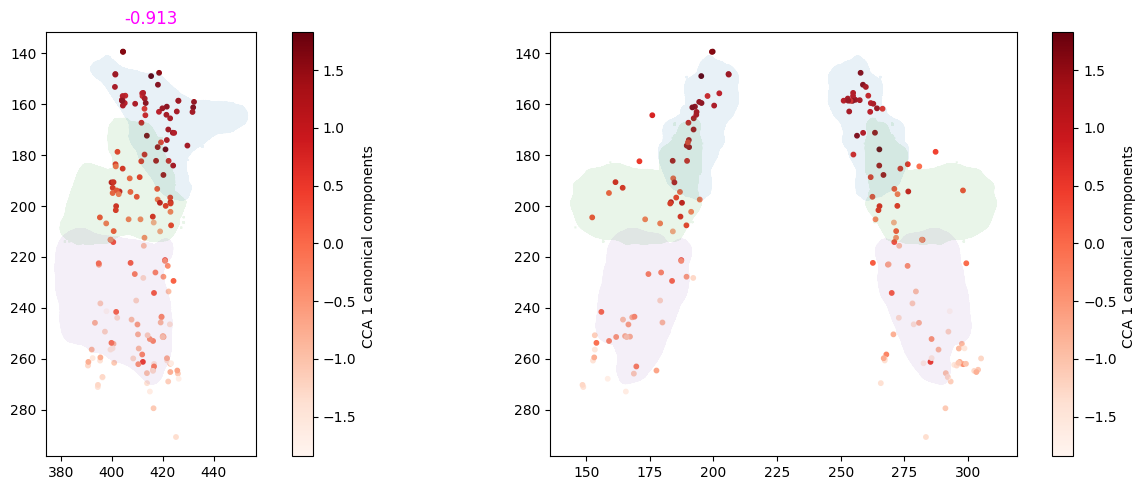

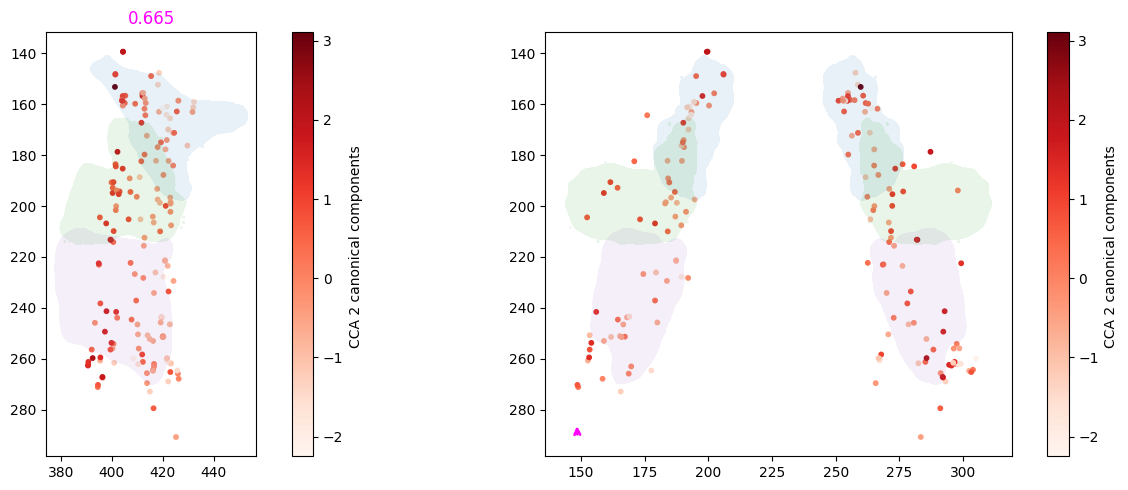

Canonical correlation for component 3 is low: 0.341. Skipping plot.


In [62]:
import sys
sys.path.append('../func/')

import cca_analysis 
cca_analysis.plot_result(adata_sub, cca, X_c, S_c)

# regularized CCA instead 

In [68]:
X_c.shape, adata_sub.shape

((165, 3), (165, 315))

In [69]:
X_pca.shape, Xs.shape

((165, 20), (165, 315))

In [70]:
X_c.shape

(165, 3)

In [77]:
Xs.shape,Ss.shape

((165, 315), (165, 3))

In [78]:
W_X.shape

(315, 315)

In [81]:
Sigma_XX.shape

(315, 315)

In [82]:
X = Xs.copy()
S = Ss.copy()

In [84]:
S.shape

(165, 3)

In [85]:
import numpy as np
from scipy.linalg import eigh
X = Xs.copy()
S = Ss.copy()
# Suppose X (n x p) and S (n x d) are already mean‑centered
n, p = X.shape
_, d = S.shape

# 1) Empirical covariances
Sigma_XX = (X.T @ X) / n         # p x p
Sigma_SS = (S.T @ S) / n         # d x d
Sigma_XS = (X.T @ S) / n         # p x d

# 2) Regularize
lambda_X = 1e-1
lambda_S = 1e-1
Sigma_XX_reg = Sigma_XX + lambda_X * np.eye(p)
Sigma_SS_reg = Sigma_SS + lambda_S * np.eye(d)

# 3) Whitening transforms
#    Σ = V Λ Vᵀ  =>  Σ^{-1/2} = V Λ^{-1/2} Vᵀ
def inv_sqrt(mat):
    vals, vecs = eigh(mat)
    return vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T

W_X = inv_sqrt(Sigma_XX_reg)     # p x p
W_S = inv_sqrt(Sigma_SS_reg)     # d x d

# 4) SVD on whitened cross‑covariance
M = W_X @ Sigma_XS @ W_S        # p x d
U, canonical_correlations, Vt = np.linalg.svd(M, full_matrices=False)

# The canonical weights are then:
#   w_X = Σ_{XX}^{-1/2} * U[:,i],  w_S = Σ_{SS}^{-1/2} * Vt.T[:,i]
n_components = 3
X_c = W_X @ U[:, :n_components]      # p x k
S_c = W_S @ Vt.T[:, :n_components]   # d x k

# s[i] are the regularized canonical correlations.
print("Regularized canonical correlations:", s[:n_components])


Regularized canonical correlations: [0.92791558 0.90270916 0.77521801]


In [86]:
X_c.shape

(315, 3)

In [87]:
adata_sub.shape

(165, 315)

ValueError: 'c' argument has 315 elements, which is inconsistent with 'x' and 'y' with size 165.

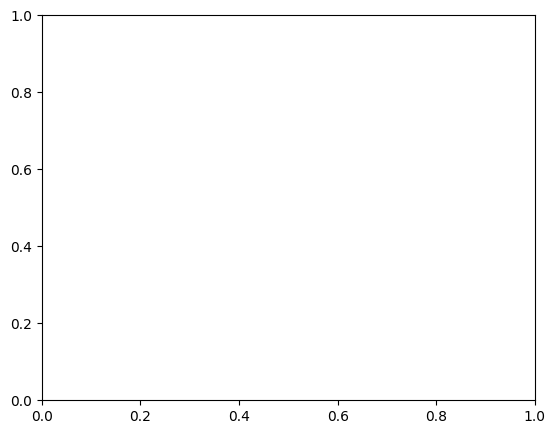

In [74]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
start_point = (np.min(adata_sub.obsm['spatial'][:, 0]), np.max(adata_sub.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

In [75]:
adata_sub.shape, X_c.shape

((165, 315), (315, 3))

Canonical correlations: [0.9999999999999993, 0.9999999999999989, 0.9999999999999962]


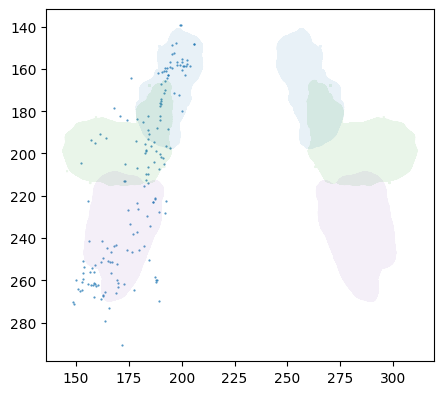

In [33]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_sub, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

Text(0.5, 1.0, 'rotations')

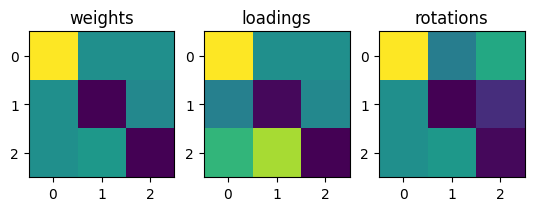

In [34]:
plt.subplot(1,3,1);plt.imshow(cca.y_weights_);plt.title('weights')
plt.subplot(1,3,2);plt.imshow(cca.y_loadings_);plt.title('loadings')
plt.subplot(1,3,3);plt.imshow(cca.y_rotations_);plt.title('rotations')

In [35]:
cca.y_weights_

array([[ 1.00000000e+00, -2.17903086e-15, -0.00000000e+00],
       [-2.16914056e-15, -9.97735121e-01, -6.72653553e-02],
       [ 1.54801799e-16,  6.72653553e-02, -9.97735121e-01]])

In [36]:
S_c.shape, X_c.shape

((165, 3), (165, 3))

In [37]:
canonical_correlations

[0.9999999999999993, 0.9999999999999989, 0.9999999999999962]

### notes
- X_c and S_c are now the canonical variates for X and S, respectively.


In [38]:
np.argmax(cca.x_weights_[:,0])  # for X

253

# gene components?
X_c. S_c are U and V correspondingly 

In [56]:
k = 0
cca.y_weights_[:,k]

array([-1.00000000e+00,  9.93836040e-17,  5.13481954e-16])

In [57]:
k = 0
cca.y_weights_

array([[-1.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [ 9.93836040e-17,  1.00000000e+00, -0.00000000e+00],
       [ 5.13481954e-16, -2.46115946e-16, -1.00000000e+00]])

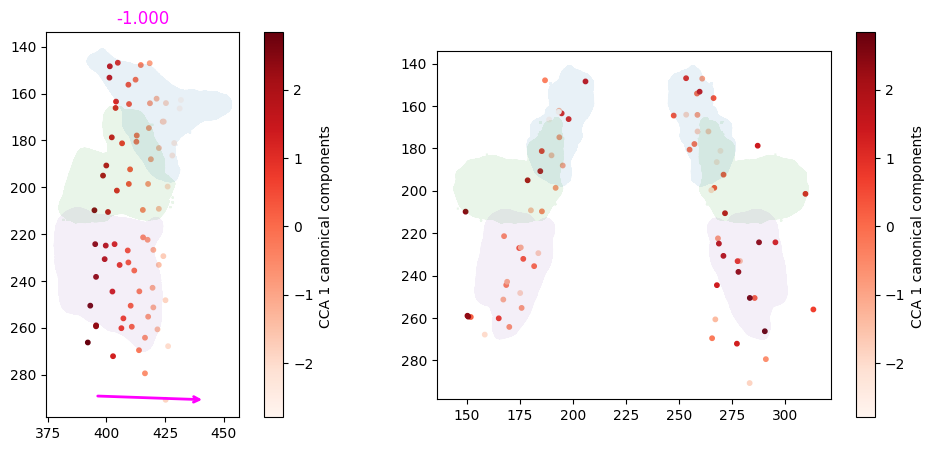

<Figure size 640x480 with 0 Axes>

In [58]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
start_point = (np.min(adata_sub.obsm['spatial'][:, 0]), np.max(adata_sub.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

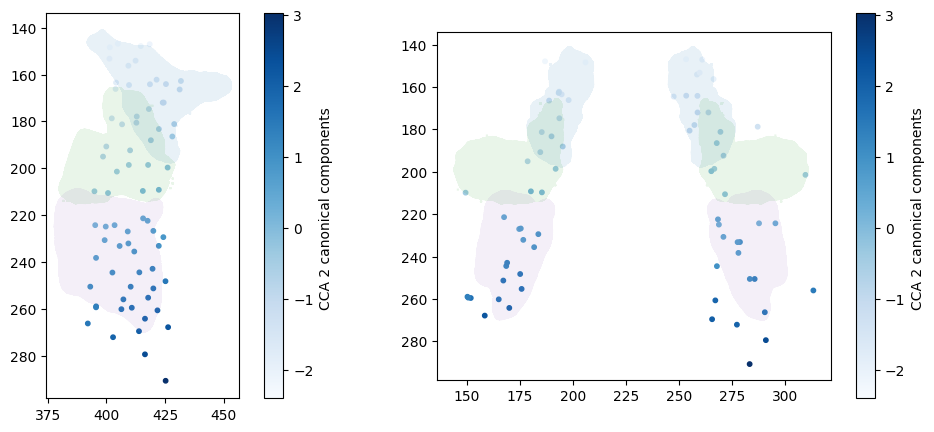

<Figure size 640x480 with 0 Axes>

In [59]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()



plt.subplot(1,2,2)

sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
start_point = (np.min(adata_sub.obsm['spatial'][:, 2]), np.min(adata_sub.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()



plt.show()
plt.tight_layout()

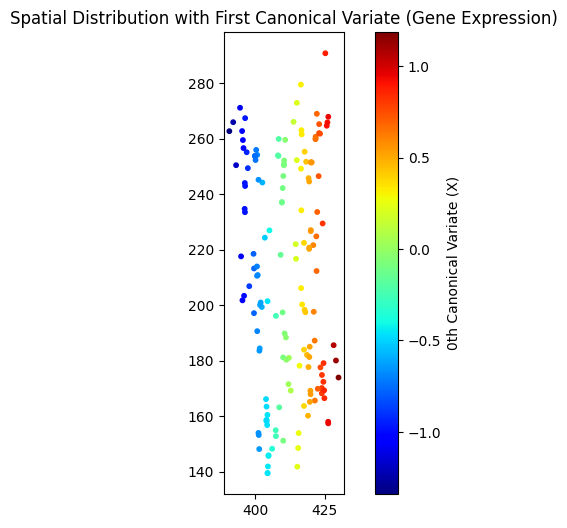

In [38]:
i = 0

plt.figure(figsize=(8, 6))
sc = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, i],cmap='jet',s=10)
plt.title("Spatial Distribution with First Canonical Variate (Gene Expression)")
plt.colorbar(sc, label=f"{i}th Canonical Variate (X)")
plt.gca().set_aspect('equal')
plt.show()


In [39]:
import pandas as pd
import seaborn as sns
import scanpy as sc

In [40]:

gene_labels = [f"Gene {i}" for i in range(adata_sub.X.shape[1])]
gene_labels = list(adata_sub.var_names)

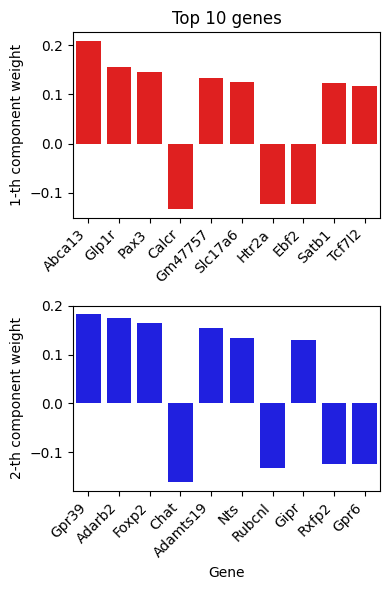

In [41]:
T = 10
k=0
loadings_1_df = pd.DataFrame({'gene': gene_labels,'loading': cca.x_weights_[:, k]})
loadings_1_df['abs_loading'] = loadings_1_df['loading'].abs()
loadings_1_sorted = loadings_1_df.sort_values('abs_loading', ascending=False)

plt.figure(figsize=(4,6))
plt.subplot(2,1,1)
sns.barplot(x='gene', y='loading', data=loadings_1_sorted.head(T), color = 'r')
plt.xticks(rotation=45, ha='right')
plt.xlabel("")
plt.ylabel(f"{k+1}-th component weight")
plt.title(f"Top {T} genes")
# plt.tight_layout()
# plt.show()


k=1
loadings_2_df = pd.DataFrame({'gene': gene_labels,'loading': cca.x_weights_[:, k]})
loadings_2_df['abs_loading'] = loadings_2_df['loading'].abs()
loadings_2_sorted = loadings_2_df.sort_values('abs_loading', ascending=False)

plt.subplot(2,1,2)
sns.barplot(x='gene', y='loading', data=loadings_2_sorted.head(T), color = 'b') 
plt.xticks(rotation=45, ha='right')
plt.xlabel("Gene")
plt.ylabel(f"{k+1}-th component weight")
# plt.title(f"Top {T} genes")
plt.tight_layout()
plt.show()

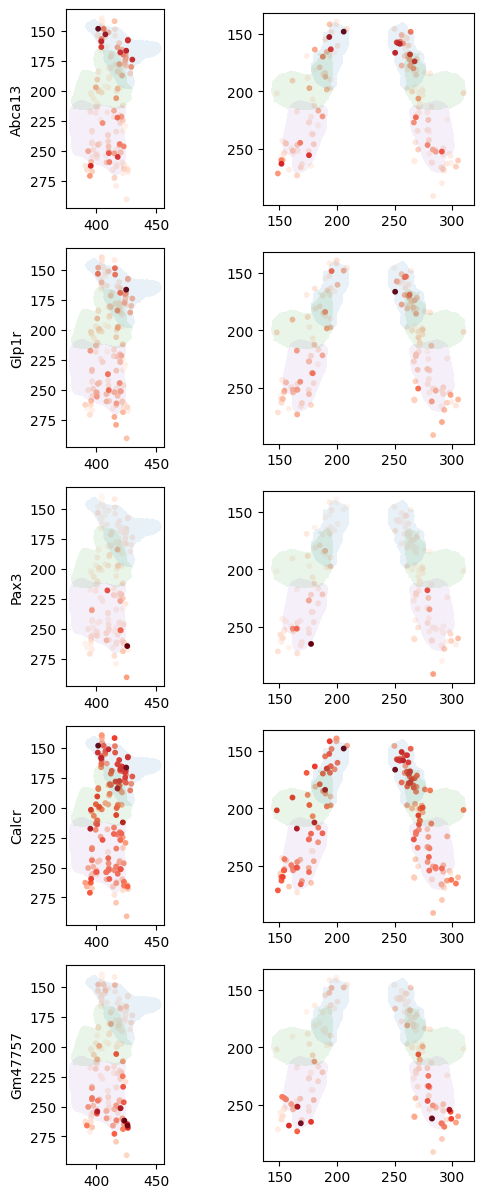

In [43]:
T = 5
fig, axes = plt.subplots(T,2,figsize=(6,3*T))

for i in range(T):
    top_gene = loadings_1_sorted.iloc[i]['gene']
    gene_index = list(adata_sub.var_names).index(top_gene)
    gene_expression = adata_sub.X[:, gene_index].toarray().flatten() if hasattr(adata_sub.X, "toarray") else adata_sub.X[:, gene_index]
    ordered = np.argsort(gene_expression)
    
    ax = axes[i,0]
    sc = ax.scatter(adata_sub.obsm['spatial'][ordered, 0], adata_sub.obsm['spatial'][ordered, 1], 
                    c=gene_expression[ordered], cmap='Reds',s=10)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_ylabel(top_gene)

    ax = axes[i,1]
    sc = ax.scatter(adata_sub.obsm['spatial'][ordered, 2], adata_sub.obsm['spatial'][ordered, 1], 
                    c=gene_expression[ordered], cmap='Reds',s=10)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()




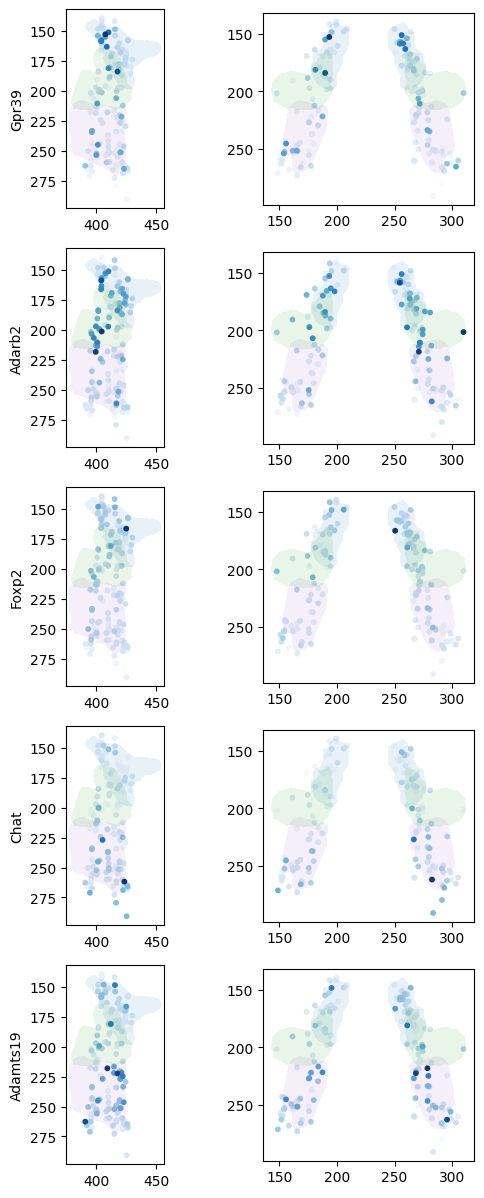

In [44]:
T = 5
fig, axes = plt.subplots(T,2,figsize=(6,3*T))

for i in range(T):
    top_gene = loadings_2_sorted.iloc[i]['gene']
    gene_index = list(adata_sub.var_names).index(top_gene)
    gene_expression = adata_sub.X[:, gene_index].toarray().flatten() if hasattr(adata_sub.X, "toarray") else adata_sub.X[:, gene_index]
    ordered = np.argsort(gene_expression)

    ax = axes[i,0]
    sc = ax.scatter(adata_sub.obsm['spatial'][ordered, 0], adata_sub.obsm['spatial'][ordered, 1],
                    c=gene_expression[ordered], cmap='Blues',s=10)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_ylabel(top_gene)

    ax = axes[i,1]
    sc = ax.scatter(adata_sub.obsm['spatial'][ordered, 2], adata_sub.obsm['spatial'][ordered, 1],
                    c=gene_expression[ordered], cmap='Blues',s=10)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()